# Загрузка датасета

In [1]:
# Аугментации
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose
from torchvision.transforms import ToTensor, Normalize

# Загрузка датасета
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader

# Модель, оптимизатор, функция потерь
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Валидация
from sklearn.metrics import classification_report

# Визуализация
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Подготовка датасета

In [3]:
# Аугментации
train_transforms = Compose([
    ToTensor(),
    Normalize((0.5), (0.5)),
    RandomHorizontalFlip(p=0.3),
    RandomVerticalFlip(p=0.3),
    RandomRotation([-10, 10])
])

val_transforms = Compose([
    ToTensor(),
    Normalize((0.5), (0.5))
]) 

In [4]:
# Установка датасета
train_dataset = FashionMNIST(root ='data/',
                             download=True, 
                             transform=train_transforms, 
                             train=True)
val_dataset = FashionMNIST(root ='data/',
                           download=True, 
                           transform=val_transforms,
                           train=False)

print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset)) 

Количество изображений в train: 60000
Количество изображений в val: 10000


In [5]:
# Создание Dataloaders
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal
T-shirt/top


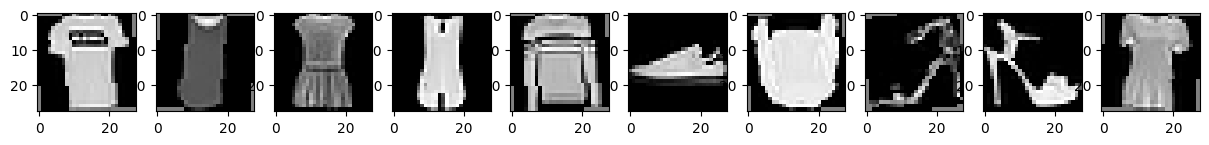

In [6]:
# Названия классов из датасета
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress',
           'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image[0], cmap='gray') 

# Модель

In [8]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding='same')
        self.pool = nn.MaxPool2d(2, 2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [9]:
model = FashionClassifier().to(device)

# Обучение

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) 

In [11]:
def train_one_epoch(epoch_index, train_model):
    running_loss = 0.
    last_loss = 0.

    progress_bar = tqdm(enumerate(train_loader), 
                        total=len(train_loader),
                        desc=f'Эпоха {epoch_index}',
                        unit='batch')
    
    for batch_index, data in progress_bar:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = train_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Суммирование ошибки за последние 100 батчей
        running_loss += loss.item()
        if batch_index % 100 == 99:
            last_loss = running_loss / 100. # средняя ошибка за 100 батчей
            progress_bar.set_postfix({'loss': f'{last_loss:.4f}'})
            running_loss = 0.

    return last_loss

In [65]:
EPOCHS = 15
best_vloss = 1e5

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    model.train(True)
    avg_loss = train_one_epoch(epoch, model)

    # Валидация
    model.eval()
    running_vloss = 0.0
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            
            voutputs = model(vinputs)
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss.item()
    avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'models/fashion_classifier/fashion_classifier_{epoch}.pt'
        torch.save(model.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

Эпоха 0


Эпоха 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:13<00:00, 272.22batch/s, loss=0.6375]


В конце эпохи ошибка train 0.6374686388671398, ошибка val 0.6135701835036278
Эпоха 1


Эпоха 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:13<00:00, 277.85batch/s, loss=0.5748]


В конце эпохи ошибка train 0.5747988414764404, ошибка val 0.5887146366715431
Эпоха 2


...

В конце эпохи ошибка train 0.44318257935345173, ошибка val 0.404697533929348
Эпоха 13


Эпоха 13: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:14<00:00, 267.57batch/s, loss=0.4505]


В конце эпохи ошибка train 0.45054140862077474, ошибка val 0.381239603894949
Эпоха 14


Эпоха 14: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:13<00:00, 273.48batch/s, loss=0.4259]


В конце эпохи ошибка train 0.42594211861491205, ошибка val 0.3983669458210468


# Валидация

In [68]:
model = FashionClassifier().to(device)
model.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [72]:
labels_predicted = []
labels_true = []

model.eval()

with torch.no_grad():
    for data in val_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        # argmax по всем примерам, так как torch.max возвращает два параметра
        # максимальные значения в выборке и позиции, на которых они находятся (argmax)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.cpu().numpy())
        labels_true.extend(labels.cpu().numpy()) 

In [73]:
print(classification_report(labels_true, labels_predicted, target_names=classes)) 

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.81      0.82      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.85      0.80      0.82      1000
       Dress       0.83      0.90      0.86      1000
        Coat       0.78      0.79      0.78      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.67      0.65      0.66      1000
     Sneaker       0.91      0.96      0.93      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.96      0.92      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



# Сравнение с многолослойным перцептроном

In [12]:
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 64),
    nn.ReLU(),
    nn.Linear(64, 10))

mlp = mlp.to(device)

In [13]:
optimizer = optim.Adam(mlp.parameters(), lr=0.01) 

In [14]:
EPOCHS = 15
best_vloss = 1e5

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    mlp.train(True)
    avg_loss = train_one_epoch(epoch, mlp)

    # Валидация
    mlp.eval()
    running_vloss = 0.0
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            
            voutputs = mlp(vinputs)
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss.item()
    avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'models/fashion_classifier_mlp/fashion_classifier_{epoch}.pt'
        torch.save(mlp.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

Эпоха 0


Эпоха 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:12<00:00, 296.52batch/s, loss=0.8597]


В конце эпохи ошибка train 0.8596667346358299, ошибка val 0.8297632995843888
Эпоха 1


Эпоха 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:12<00:00, 301.38batch/s, loss=0.8223]


В конце эпохи ошибка train 0.8222858095169068, ошибка val 0.7461376339197159
Эпоха 2


...

В конце эпохи ошибка train 0.7876820483803749, ошибка val 0.8065130551338195
Эпоха 13


Эпоха 13: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:12<00:00, 309.79batch/s, loss=0.8615]


В конце эпохи ошибка train 0.8614902727305889, ошибка val 0.7986763845801353
Эпоха 14


Эпоха 14: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:12<00:00, 303.70batch/s, loss=0.7943]


В конце эпохи ошибка train 0.7943205186724662, ошибка val 0.7544646180510521


In [15]:
mlp.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [16]:
labels_predicted = []
labels_true = []

mlp.eval()

with torch.no_grad():
    for data in val_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)

        outputs = mlp(images)
        # argmax по всем примерам, так как torch.max возвращает два параметра
        # максимальные значения в выборке и позиции, на которых они находятся (argmax)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.cpu().numpy())
        labels_true.extend(labels.cpu().numpy()) 

In [17]:
print(classification_report(labels_true, labels_predicted, target_names=classes)) 

              precision    recall  f1-score   support

 T-shirt/top       0.77      0.74      0.75      1000
     Trouser       0.99      0.89      0.94      1000
    Pullover       0.64      0.68      0.66      1000
       Dress       0.73      0.89      0.80      1000
        Coat       0.64      0.57      0.61      1000
      Sandal       0.79      0.88      0.84      1000
       Shirt       0.39      0.39      0.39      1000
     Sneaker       0.87      0.90      0.88      1000
         Bag       0.95      0.86      0.90      1000
  Ankle boot       0.95      0.86      0.90      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000

